# Shoulder Injury Risk Assessment

In [2]:
import smash_analysis as sa
from pathlib import Path

In [3]:
# Example usage:
input_video = 'badminton-smash-1.mp4'

file_path = Path(input_video)
file_stem = file_path.stem

output_video = f"{file_stem}_analyzed{file_path.suffix}"
output_kin_image = f"{file_stem}_kinematic.png"

## Kinematic Metrics Extraction

In [4]:
kin_metrics, fps = sa.extract_kinematic_metrics(input_video)

I0000 00:00:1789967392.018349 32535652 gl_context.cc:357] GL version: 2.1 (2.1 ATI-7.1.6), renderer: AMD Radeon Pro 5500M OpenGL Engine
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1789967392.147575 32536012 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1789967392.171479 32536020 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


## Smash Assessment

In [5]:
smashes = sa.find_smashes(kin_metrics, fps)
max_critical_dec = max([abs(s.critical_deceleration) for s in smashes] + [0])

assessments = sa.assess_smashes(kin_metrics=kin_metrics,
               smashes=smashes,
               max_critical_deceleration=max_critical_dec)

## Visualization

### Graph

Figure saved as badminton-smash-1_kinematic.png


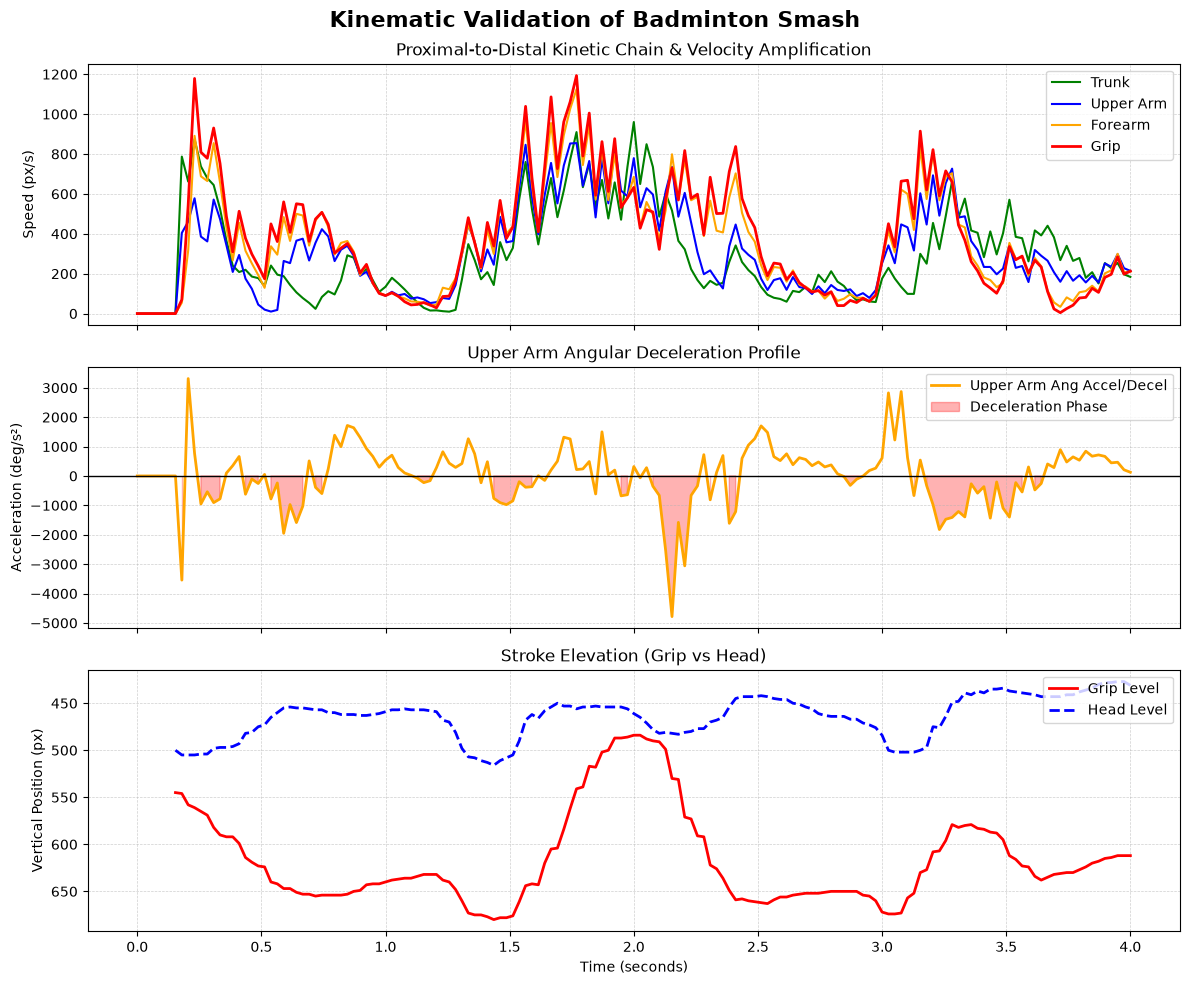

In [6]:
sa.plot_smashes_kinematics(kin_metrics, fps,
                         smashes=smashes,
                         assessments=assessments,
                         fig_name=output_kin_image)

### Overlaying Video

In [7]:
sa.overlay_kinematic_assessment(
    input_video_path=input_video,
    output_video_path=output_video,
    metrics=kin_metrics,
    smashes=smashes,
    assessments=assessments,
    scale_linear=0.2,
    scale_ang_accel=0.05,
    show_labels=True,
    # pixels_per_meter=120
)

Overwriting: Deleting existing file 'badminton-smash-1_analyzed.mp4'...
Rendering kinematic assessment video...
Success! Saved to badminton-smash-1_analyzed.mp4


2026-09-21 17:10:01.210 python[68856:32535652] WARNING: -finishWriting should not be called on the main thread.


## All-in-One Analysis

In [2]:
def analyze_video(input_video):
    file_path = Path(input_video)
    file_stem = file_path.stem

    output_video = f"{file_stem}_analyzed{file_path.suffix}"
    output_kin_image = f"{file_stem}_kinematic.png"

    kin_metrics, fps = sa.extract_kinematic_metrics(input_video)

    smashes = sa.find_smashes(kin_metrics, fps)

    max_critical_dec = max([abs(s.critical_deceleration) for s in smashes] + [0])

    assessments = sa.assess_smashes(kin_metrics=kin_metrics,
                   smashes=smashes,
                   max_critical_deceleration=max_critical_dec)

    sa.plot_smashes_kinematics(kin_metrics, fps,
                             smashes=smashes,
                             assessments=assessments,
                             fig_name=output_kin_image)

    sa.overlay_kinematic_assessment(
        input_video_path=input_video,
        output_video_path=output_video,
        metrics=kin_metrics,
        smashes=smashes,
        assessments=assessments,
        scale_linear=0.2,
        scale_ang_accel=0.05,
        show_labels=True,
        # pixels_per_meter=120
    )

I0000 00:00:1789951164.470403 32299413 gl_context.cc:357] GL version: 2.1 (2.1 ATI-7.1.6), renderer: AMD Radeon Pro 5500M OpenGL Engine
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1789951164.668533 32299692 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1789951164.698281 32299692 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Figure saved as badminton-smash-1_kinematic.png


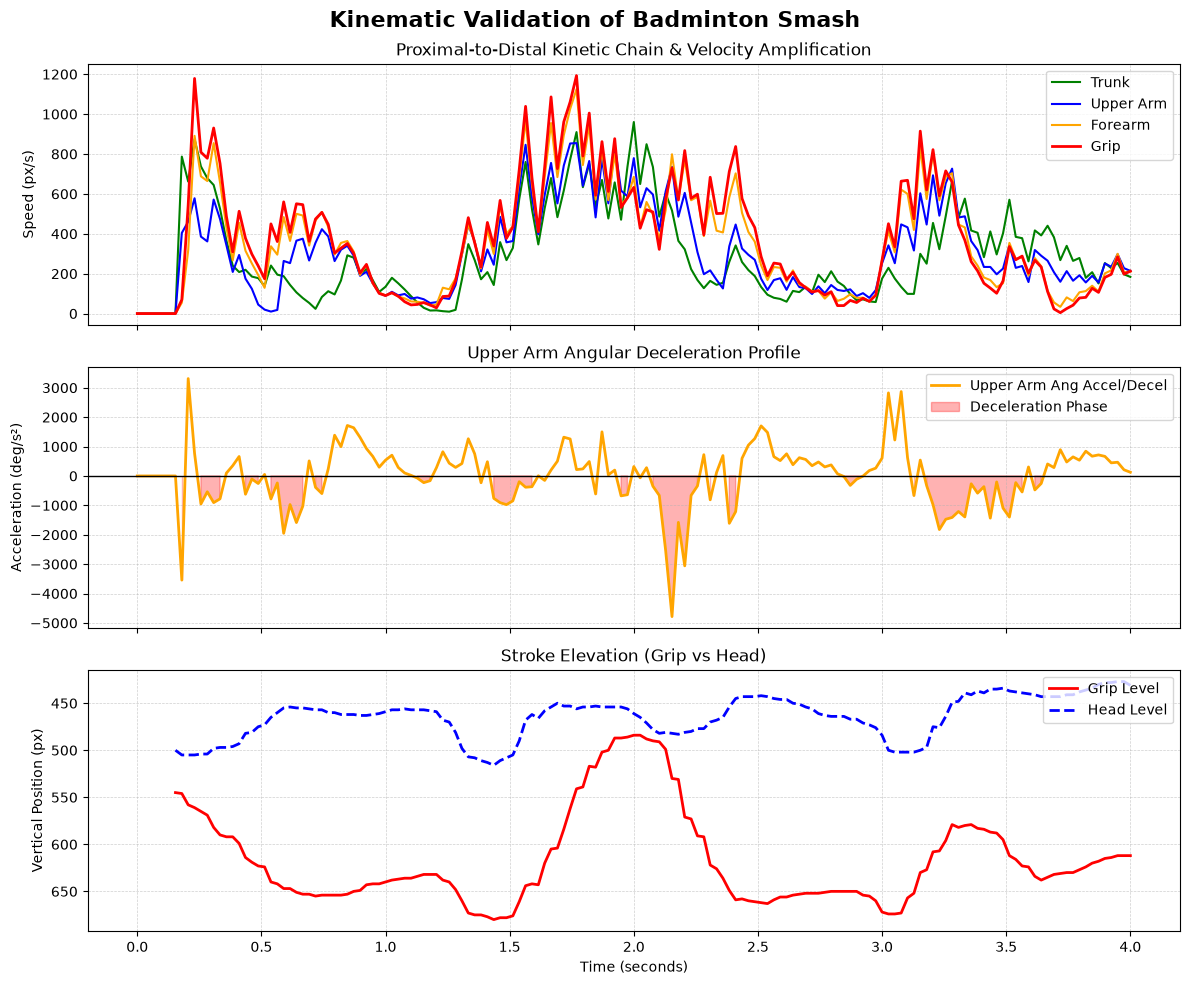

Overwriting: Deleting existing file 'badminton-smash-1_analyzed.mp4'...
Rendering kinematic assessment video...
Success! Saved to badminton-smash-1_analyzed.mp4


2026-09-21 12:39:33.402 python[62360:32299413] WARNING: -finishWriting should not be called on the main thread.


In [3]:
analyze_video('badminton-smash-1.mp4')

I0000 00:00:1789949079.857118 31564627 gl_context.cc:357] GL version: 2.1 (2.1 ATI-7.1.6), renderer: AMD Radeon Pro 5500M OpenGL Engine
W0000 00:00:1789949079.958209 32271470 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1789949079.971274 32271470 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Figure saved as 10.32.51_kinematic.png


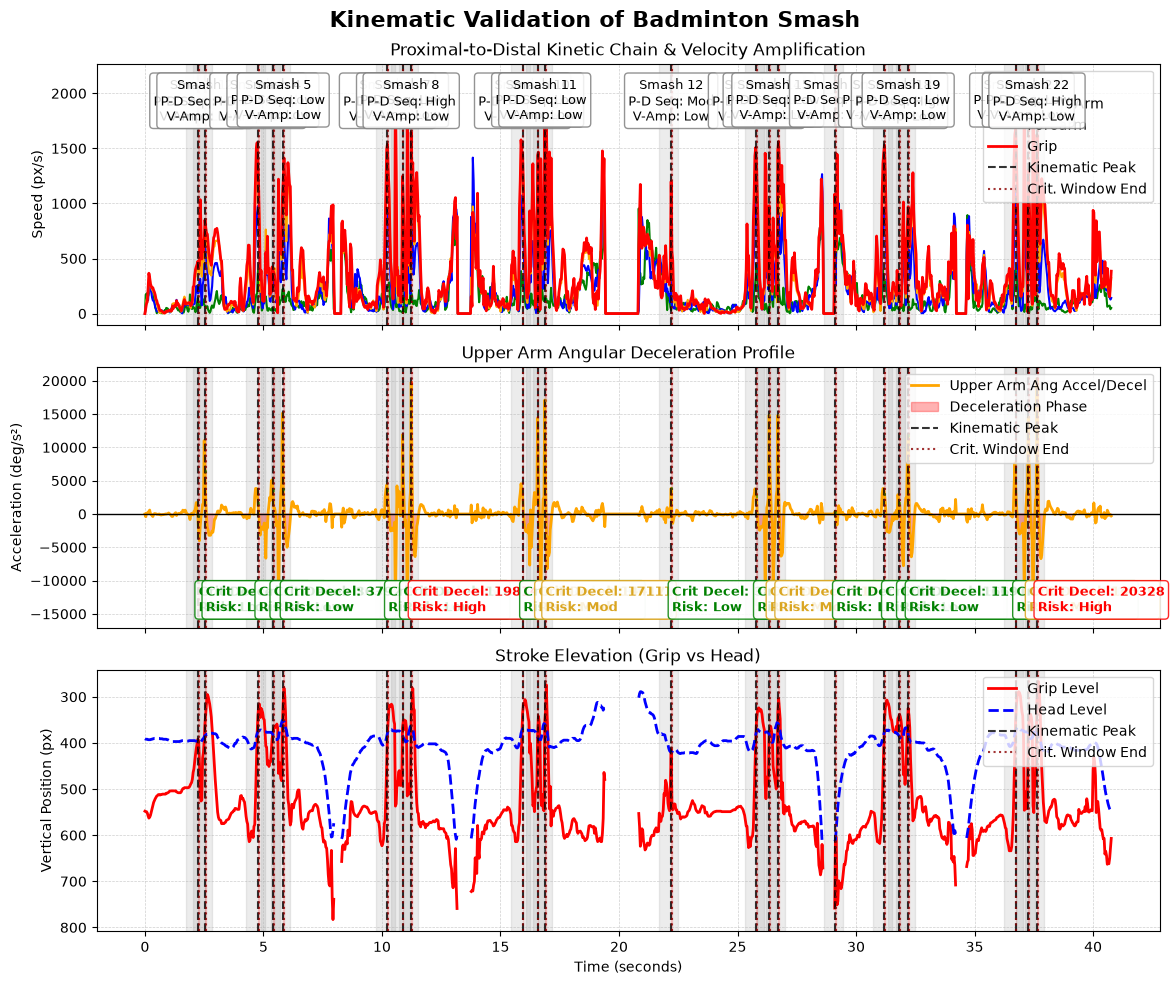

Overwriting: Deleting existing file '10.32.51_analyzed.mp4'...
Rendering kinematic assessment video...
Success! Saved to 10.32.51_analyzed.mp4


2026-09-21 12:05:15.679 python[41149:31564627] WARNING: -finishWriting should not be called on the main thread.


In [94]:
analyze_video('10.32.51.mp4')
